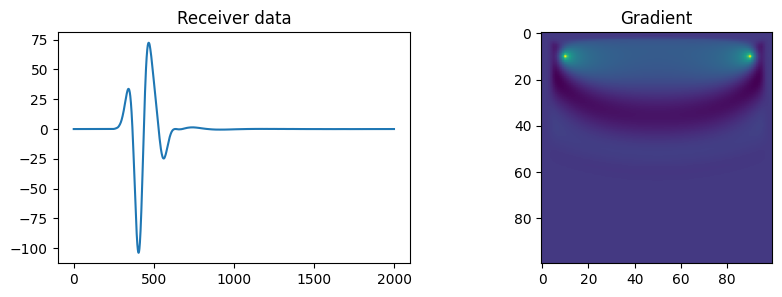

In [ ]:
import torch
import sys 
from pathlib import Path
src_path=Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import DeepGPR
import matplotlib.pyplot as plt


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set up the parameters and models
dx=0.02
dt=3e-11
nt=2000
er = torch.ones(100, 100,1) * 2  
er[50:,:]=5
se = torch.zeros_like(er)  
er.requires_grad_()
source_location=torch.tensor([[[10,10,0]]],device=device,dtype=torch.int)
receiver_location=torch.tensor([[[10,90,0]]],device=device,dtype=torch.int)
freq=2e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)

#forward modeling
r = DeepGPR.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=er, se=se
)

(r[-1]**2).sum().backward()

_, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(r[-1].detach().flatten().cpu().numpy())
ax[0].set_title("Receiver data")
ax[1].imshow(er.grad.detach())
ax[1].set_title("Gradient")
plt.show()
